# **AI-Based Insulator Health Detection for Spot Maintenance using YOLO + Roboflow Dataset**

## **Objective**
Develop and train a custom YOLO-based object detection model for **Insulator Health Detection for Spot Maintenance** using a **Roboflow dataset and the Ultralytics YOLO**.

The objective is to leverage Artificial Intelligence and Computer Vision to automatically identify and classify visible insulator conditions from images or video footage, enabling utilities to move from reactive inspection and maintenance toward spot and condition-based maintenance.


## **Project Idea**
Insulators are critical components of EHT and HT transmission and distribution networks, providing electrical insulation while mechanically supporting conductors. Since these assets are often installed at significant heights and in difficult-to-access locations, their inspection can be time-consuming, resource-intensive, and potentially hazardous for field personnel.

The proposed solution utilizes drones/UAVs equipped with high-resolution cameras to capture images and videos of installed insulators. These visual datasets can then be processed through a trained YOLO deep-learning model to automatically detect and identify visible signs of insulator health deterioration or defects.

The detected conditions can be used to support spot maintenance planning, allowing utility teams to prioritize assets requiring further inspection, repair, or replacement before the condition develops into a major failure.


## **Future Scope**

The model can be further enhanced to incorporate severity classification, asset-level risk scoring, GIS-based visualization, automated inspection reports, and integration with utility maintenance systems.

Ultimately, the concept can evolve into an AI-powered predictive asset health monitoring solution for transmission and distribution networks.

## Workflow

```text
Roboflow Dataset → Download YOLOv8 Format → Train YOLO → Evaluate → Test → Save Model
```

## Step 1: Install Required Libraries

In [1]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 3.9 MB/s eta 0:00:00


## Step 2: Import Libraries

In [2]:
from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import Image, display
from google.colab import files

import os, glob, yaml
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Libraries imported successfully.


## Step 3: Connect Roboflow Dataset

Replace the placeholders with your Roboflow details.

How to get this:
1. Open your Roboflow project.
2. Click **Download Dataset**.
3. Select **YOLOv8** format.
4. Copy your workspace, project, version, and API key.

Example:
```python
rf = Roboflow(api_key="abc123")
project = rf.workspace("my-workspace").project("weapon-detection")
version = project.version(1)
dataset = version.download("yolov8")
```

In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="zW93fKW8MyzdfNrZnFr6")
project = rf.workspace("university-8jfuz").project("insulator-faults-detection-xntd2")
version = project.version(18)
dataset = version.download("yolov8")

print("Dataset downloaded at:", dataset.location)

print("Dataset downloaded successfully.")
print("Dataset location:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to INSULATOR-FAULTS-DETECTION-18 in yolov8:: 100%|██████████| 18269/18269 [00:02<00:00, 7107.04it/s] 

Dataset downloaded at: /content/INSULATOR-FAULTS-DETECTION-18
Dataset downloaded successfully.
Dataset location: /content/INSULATOR-FAULTS-DETECTION-18


## Step 4: Check Dataset Files

In [4]:
dataset_path = dataset.location
data_yaml_path = os.path.join(dataset_path, "data.yaml")

print("Dataset path:", dataset_path)
print("data.yaml exists:", os.path.exists(data_yaml_path))

print("\nDataset folder content:")
for item in os.listdir(dataset_path):
    print("-", item)

Dataset path: /content/INSULATOR-FAULTS-DETECTION-18
data.yaml exists: True

Dataset folder content:
- README.roboflow.txt
- data.yaml
- README.dataset.txt
- valid
- test
- train


## Step 5: Read `data.yaml` and Class Names

In [5]:
with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

class_names = data_yaml.get("names", [])
print("\nClasses:", class_names)
print("Number of classes:", len(class_names))

{'names': ['Glass_Dirty', 'Glass_Loss', 'Polyme_Dirty', 'broken disc', 'insulator', 'pollution-flashover'], 'nc': 6, 'roboflow': {'license': 'Public Domain', 'project': 'insulator-faults-detection-xntd2', 'url': 'https://universe.roboflow.com/university-8jfuz/insulator-faults-detection-xntd2/dataset/18', 'version': 18, 'workspace': 'university-8jfuz'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}

Classes: ['Glass_Dirty', 'Glass_Loss', 'Polyme_Dirty', 'broken disc', 'insulator', 'pollution-flashover']
Number of classes: 6


## Step 6: Count Images in Train, Validation, and Test Sets

In [6]:
def count_images(folder):
    exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]
    return sum(len(glob.glob(os.path.join(folder, ext))) for ext in exts)

train_img_dir = os.path.join(dataset_path, "train", "images")
valid_img_dir = os.path.join(dataset_path, "valid", "images")
test_img_dir = os.path.join(dataset_path, "test", "images")

counts = {
    "Train Images": count_images(train_img_dir),
    "Validation Images": count_images(valid_img_dir),
    "Test Images": count_images(test_img_dir)
}

pd.DataFrame([counts])

,Train Images,Validation Images,Test Images
0,8028,715,389


## Step 7: Preview Sample Training Images

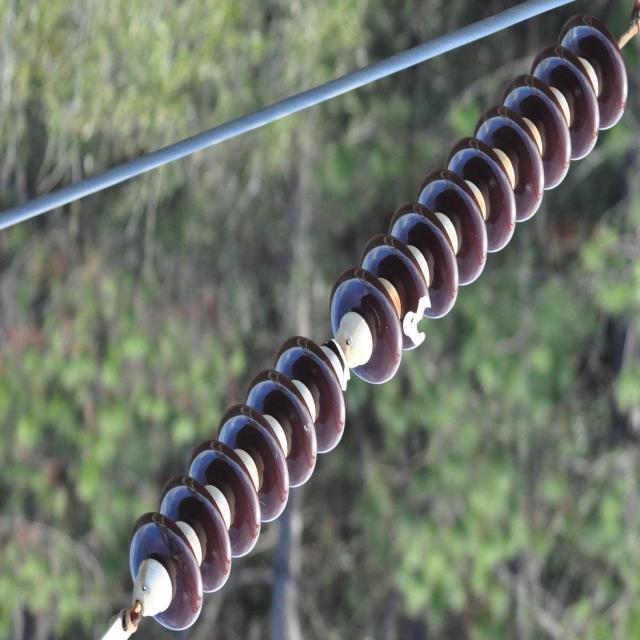

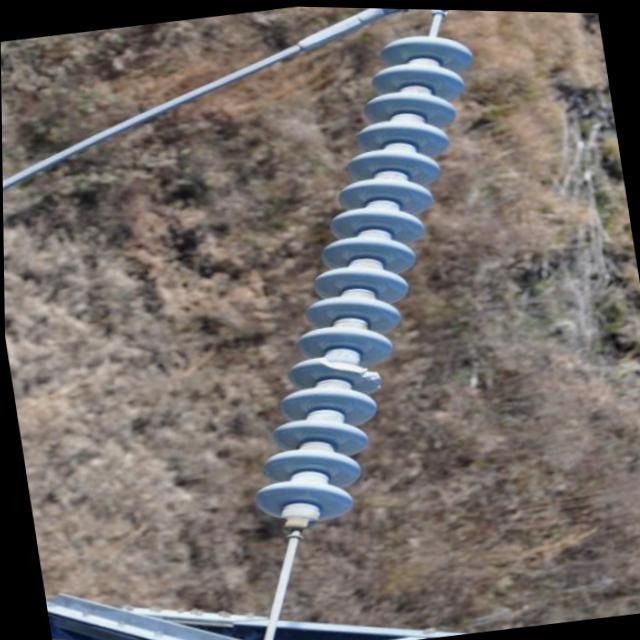

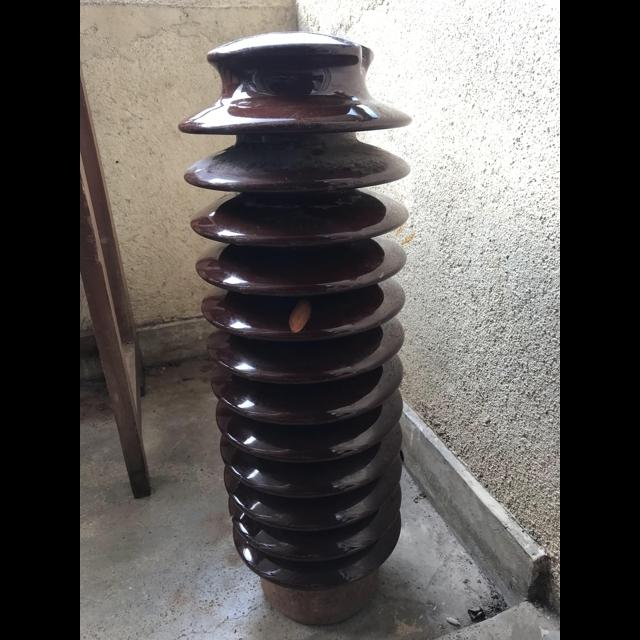

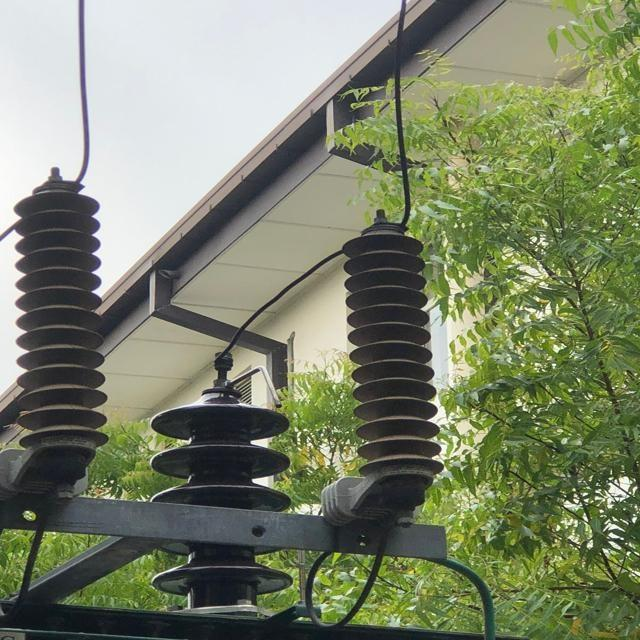

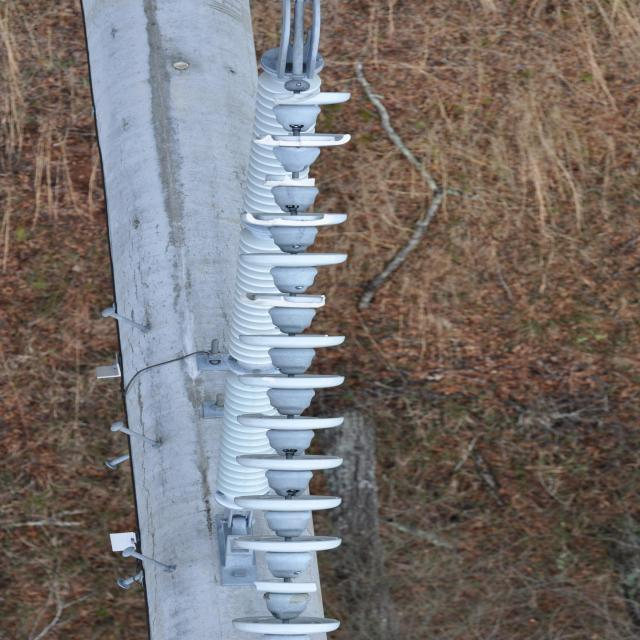

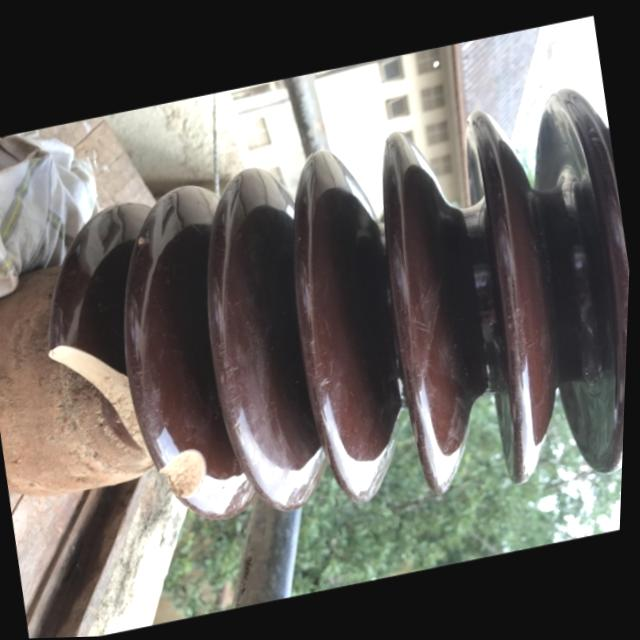

In [7]:
sample_images = glob.glob(os.path.join(train_img_dir, "*"))[:6]

for img in sample_images:
    display(Image(filename=img, width=400))

## Step 8: Load Pretrained YOLO Model

Recommended for lab:
- `yolov8n.pt` = fast and lightweight
- `yolov8s.pt` = better accuracy but slower

In [8]:
model = YOLO("yolov8n.pt")
print("YOLOv8 nano model loaded successfully.")

YOLOv8 nano model loaded successfully.


## Step 9: Train Insulator Health Detection Model

Note: the model is performing best at epochs=50 and imgsz=800. However, due to limitation of GPU. It is restricted to epochs =30.

In [9]:
results = model.train(
    data=data_yaml_path,
    epochs=30,
    imgsz=800,
    batch=8,
    name="Insulator_Faults_Detection_yolov8_roboflow"
)

Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/INSULATOR-FAULTS-DETECTION-18/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Insulator_Faults_Detection_yo

## Step 10: Display Training Results

Important files:
- `results.png`
- `confusion_matrix.png`
- `PR_curve.png`
- `F1_curve.png`


 results.png


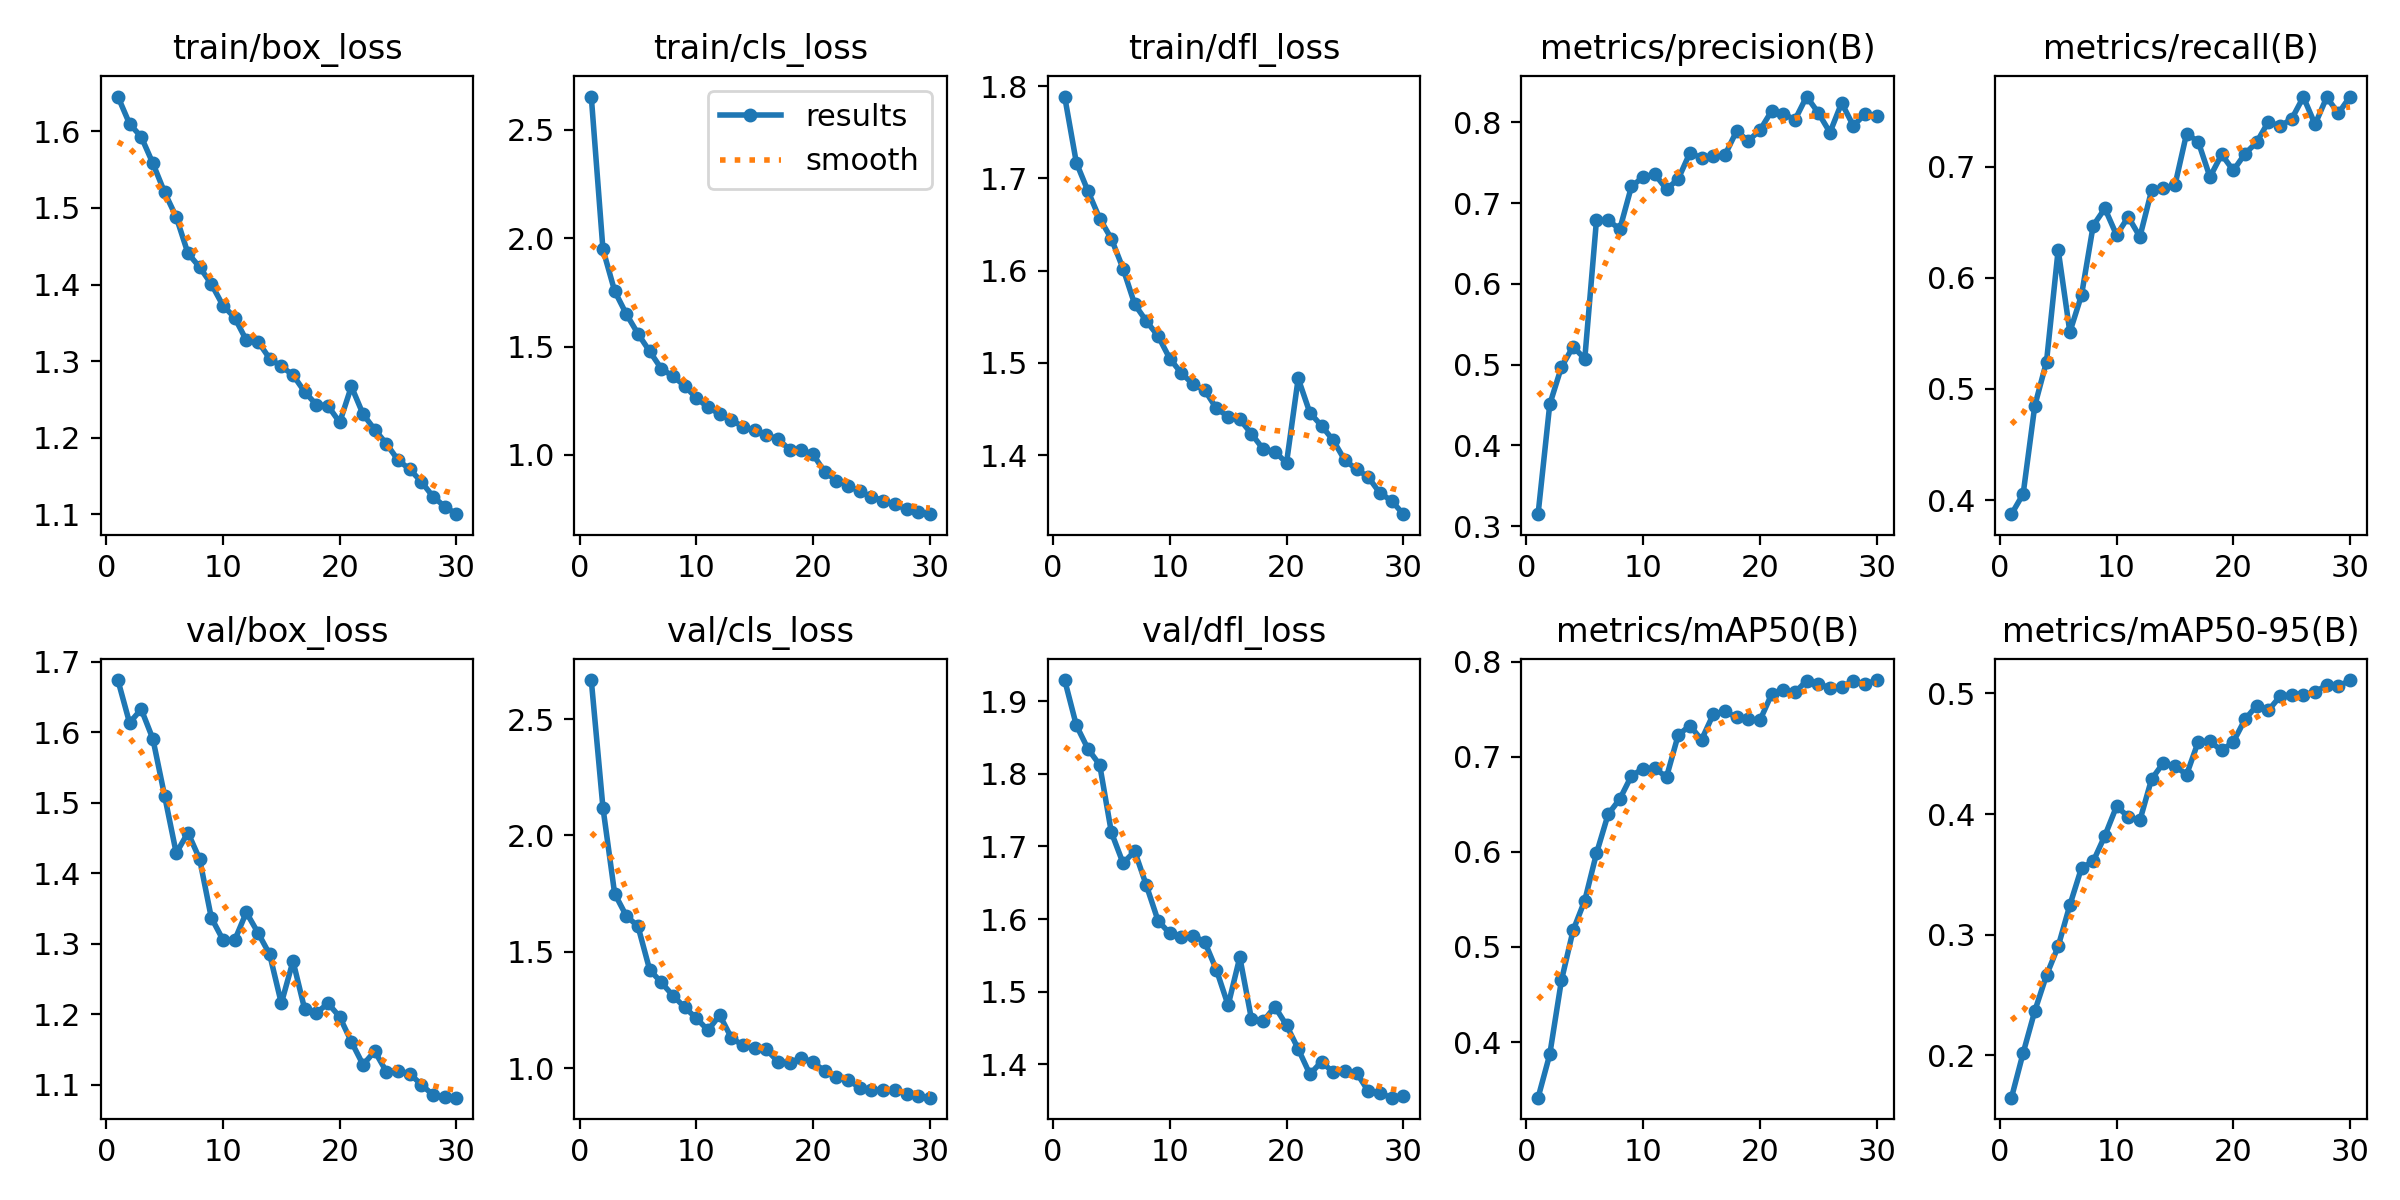


 confusion_matrix.png


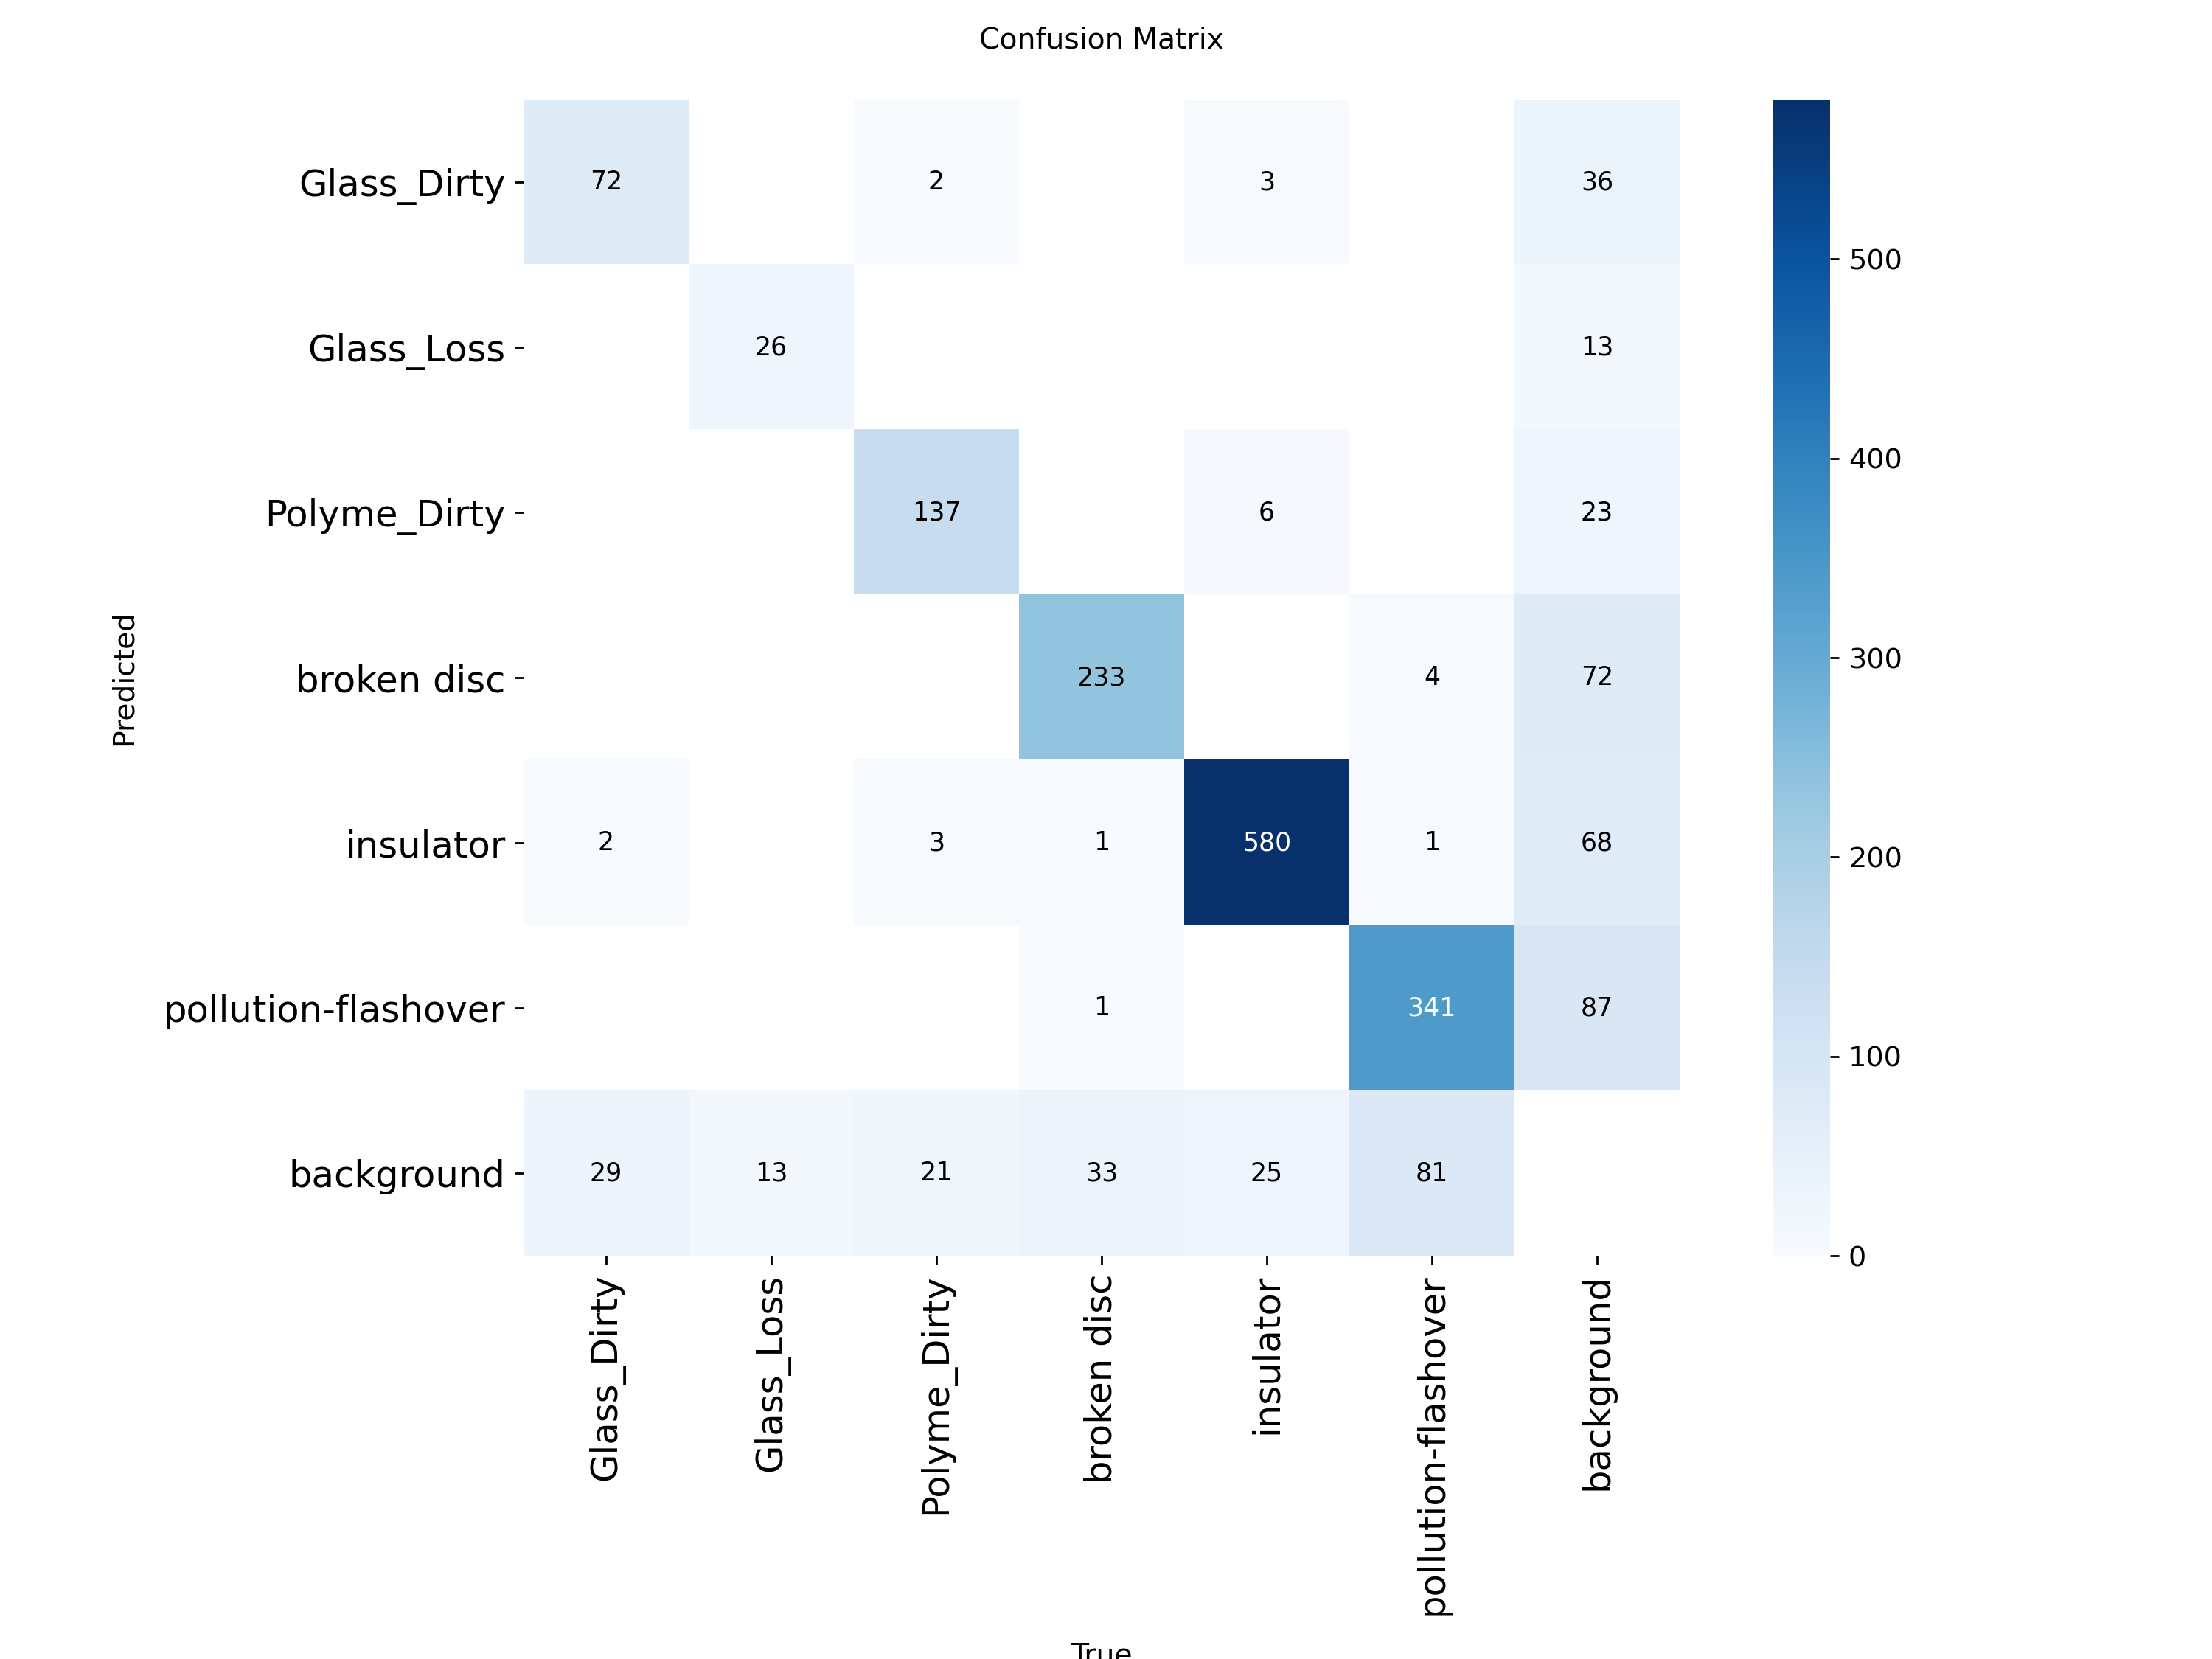

Not found: PR_curve.png
Not found: F1_curve.png
Not found: P_curve.png
Not found: R_curve.png


In [10]:
train_run_dir = "runs/detect/Insulator_Faults_Detection_yolov8_roboflow"

result_files = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]

for file in result_files:
    path = os.path.join(train_run_dir, file)
    if os.path.exists(path):
        print("\n", file)
        display(Image(filename=path, width=800))
    else:
        print("Not found:", file)

## Step 11: Validate the Trained Model

In [11]:
best_model_path = os.path.join(train_run_dir, "weights", "best.pt")
best_model = YOLO(best_model_path)

metrics = best_model.val(data=data_yaml_path)

print("Validation completed.")

Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1109.4±362.2 MB/s, size: 42.7 KB)
val: Scanning /content/INSULATOR-FAULTS-DETECTION-18/valid/labels.cache... 715 images, 1 backgrounds, 43 corrupt: 100% ━━━━━━━━━━━━ 715/715 130.4Mit/s 0.0s
val: /content/INSULATOR-FAULTS-DETECTION-18/valid/images/110_dno-26-_jpg.rf.4a02da1f70c6e9d624c146d3234d451f.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/INSULATOR-FAULTS-DETECTION-18/valid/images/110_qt-62-_jpg.rf.4e82f75beb68878f10b30be22dbb0e3e.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/INSULATOR-FAULTS-DETECTION-18/valid/images/110kv_tth-2-_jpg.rf.c91179c235a7573c3d3279ad3702989e.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/INSULATOR-FAULTS-DETECTION-18/valid/

## Step 12: Test on Roboflow Test Images

In [12]:
test_results = best_model.predict(
    source=test_img_dir,
    conf=0.4,
    save=True,
    name="Insulator_Faults_Detection_test_predictions"
)

print("Prediction completed on test images.")


image 1/389 /content/INSULATOR-FAULTS-DETECTION-18/test/images/000000795v_jpg.rf.440815b4f6ade08fac9010a907d2fb77.jpg: 800x800 1 broken disc, 1 insulator, 9.6ms
image 2/389 /content/INSULATOR-FAULTS-DETECTION-18/test/images/000006140v_jpg.rf.db49cd577ded725d635242b79b6c7ae2.jpg: 800x800 1 broken disc, 1 insulator, 9.7ms
image 3/389 /content/INSULATOR-FAULTS-DETECTION-18/test/images/100136_jpg.rf.2eabb3ec27a755a6c6589e881f6d6318.jpg: 800x800 2 broken discs, 2 insulators, 9.6ms
image 4/389 /content/INSULATOR-FAULTS-DETECTION-18/test/images/100136v_jpg.rf.2570655b87713a4e30766c6298eb03bc.jpg: 800x800 2 broken discs, 2 insulators, 9.6ms
image 5/389 /content/INSULATOR-FAULTS-DETECTION-18/test/images/100200_jpg.rf.eccc219c5e093a7c85c96b6f86517c1a.jpg: 800x800 1 insulator, 5 pollution-flashovers, 9.6ms
image 6/389 /content/INSULATOR-FAULTS-DETECTION-18/test/images/100220_jpg.rf.827a14c4e7ee7d15ae196cae7ee31ef5.jpg: 800x800 2 broken discs, 1 insulator, 9.7ms
image 7/389 /content/INSULATOR-FAU

## Step 13: Display Test Prediction Images

Number of predicted images: 389


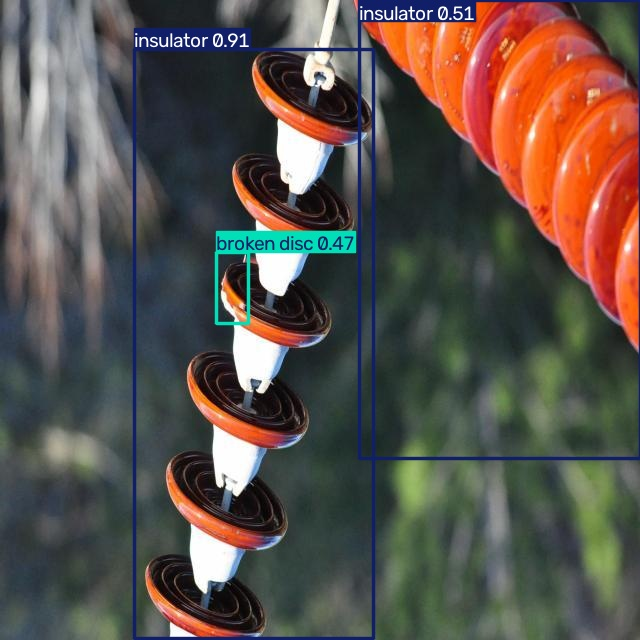

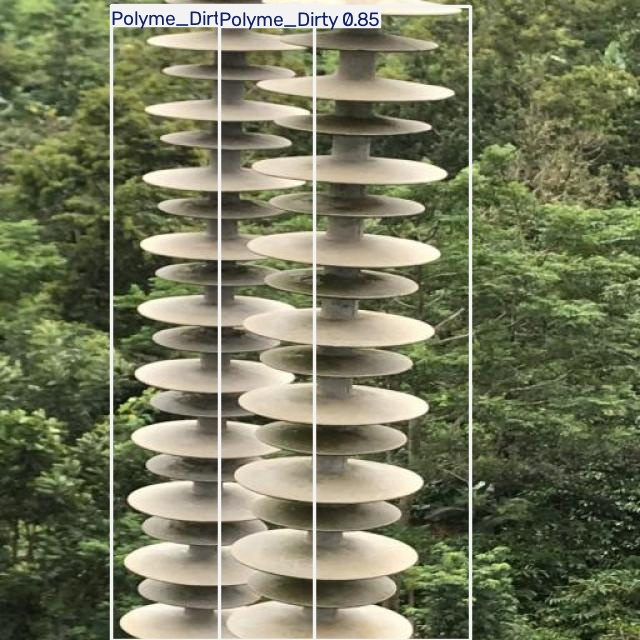

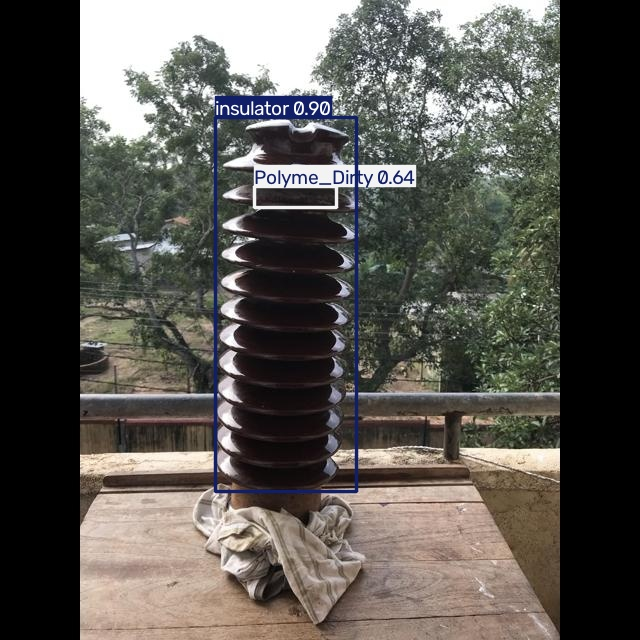

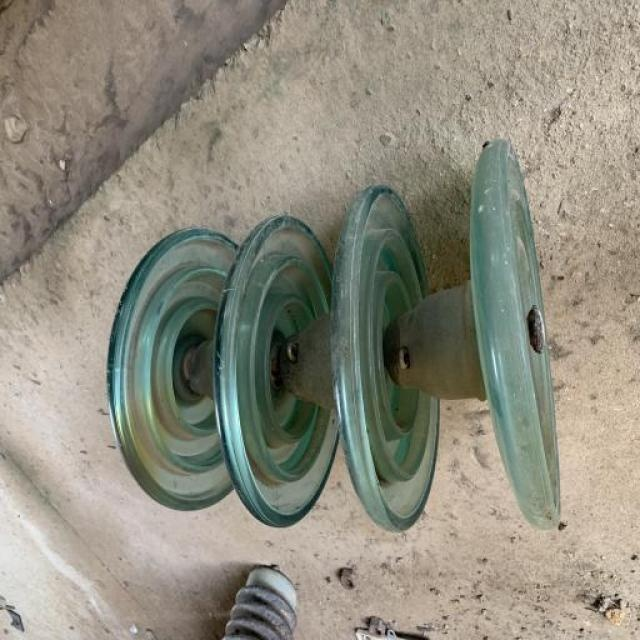

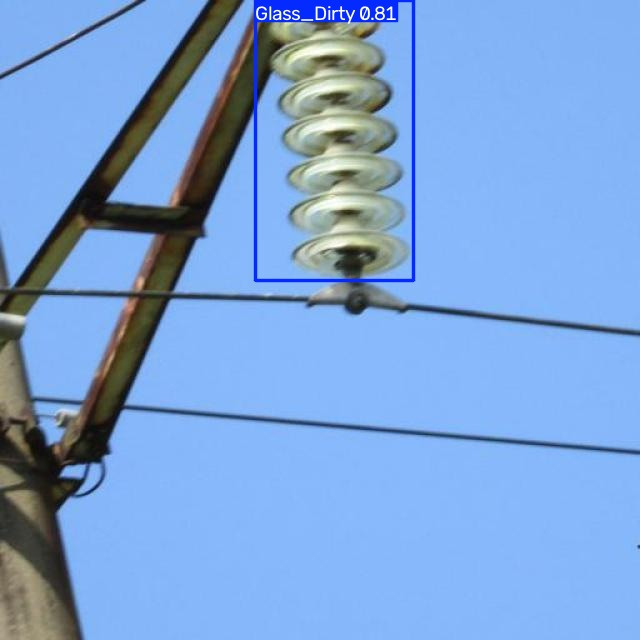

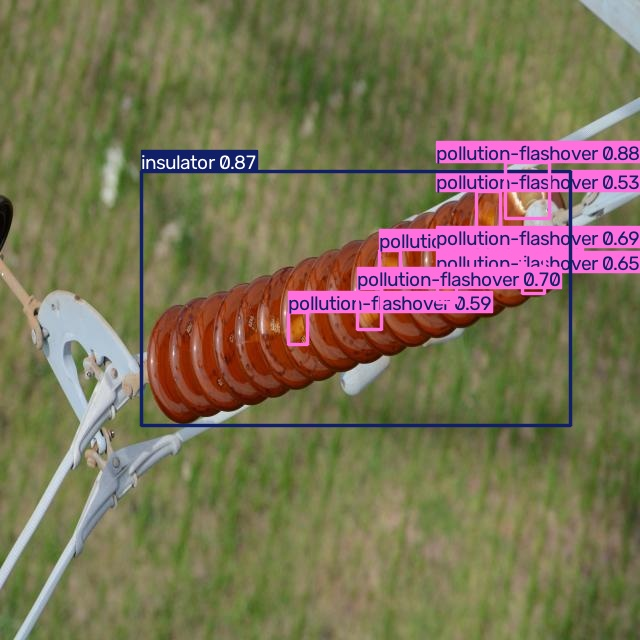

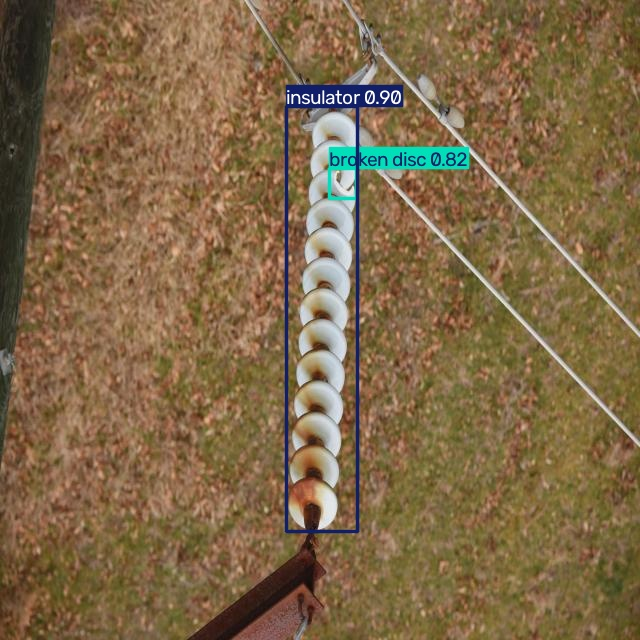

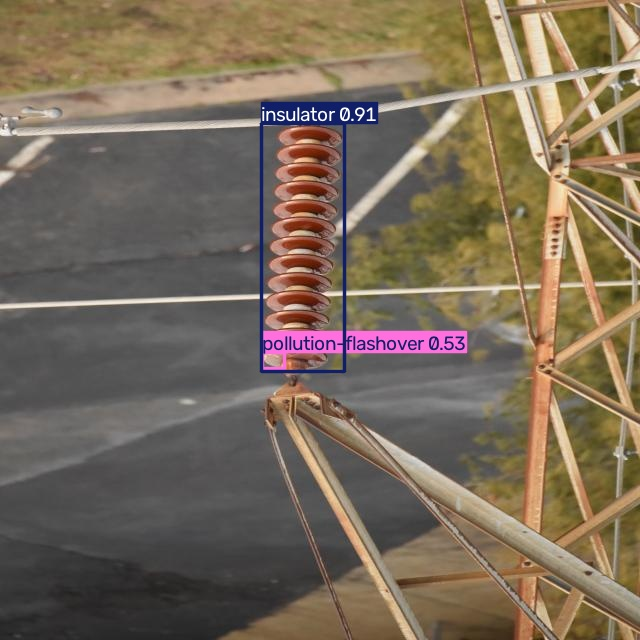

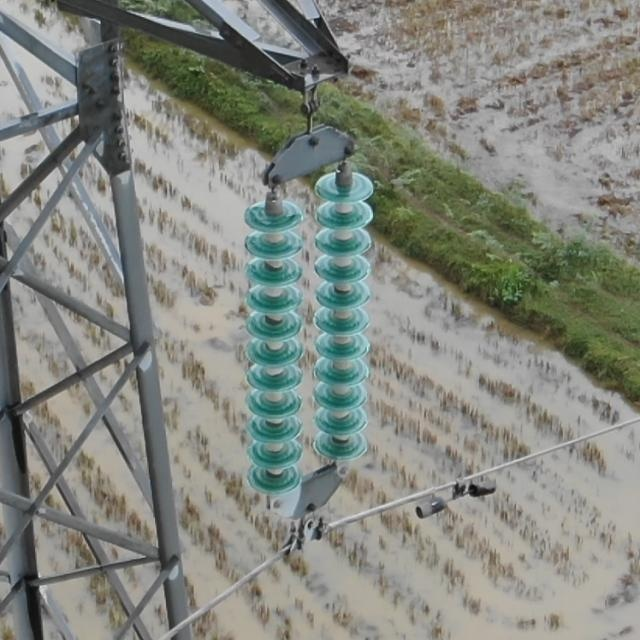

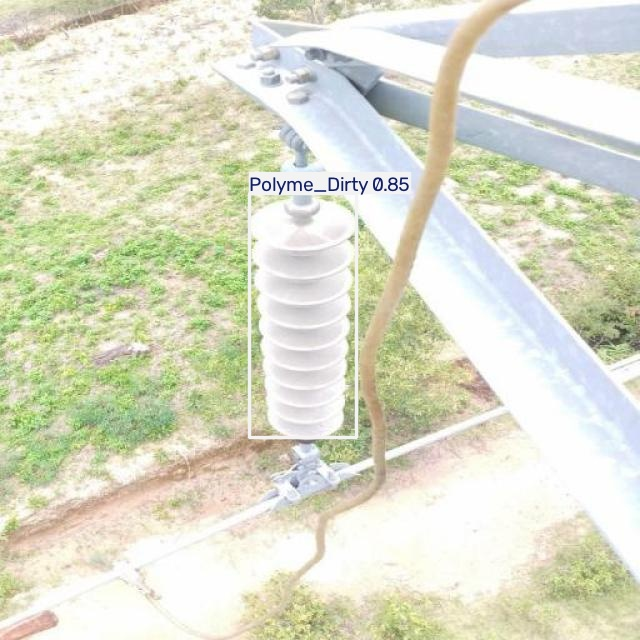

In [13]:
prediction_dir = "runs/detect/Insulator_Faults_Detection_test_predictions"
predicted_images = glob.glob(os.path.join(prediction_dir, "*"))

print("Number of predicted images:", len(predicted_images))

for img in predicted_images[:10]:
    display(Image(filename=img, width=600))

## Step 14: Test on a New Uploaded Image

In [22]:
uploaded = files.upload()
uploaded_image = list(uploaded.keys())[0]

single_result = best_model.predict(
    source=uploaded_image,
    conf=0.4,
    save=True,
    name="Insulator_Faults_Detection_uploaded_image"
)

print("Prediction completed on uploaded image.")

Saving images (2).jpg to images (2) (1).jpg

image 1/1 /content/images (2) (1).jpg: 544x800 1 broken disc, 3 insulators, 8.7ms
Speed: 3.0ms preprocess, 8.7ms inference, 1.8ms postprocess per image at shape (1, 3, 544, 800)
Results saved to /content/runs/detect/Insulator_Faults_Detection_uploaded_image
Prediction completed on uploaded image.


## Step 15: Display Uploaded Image Prediction

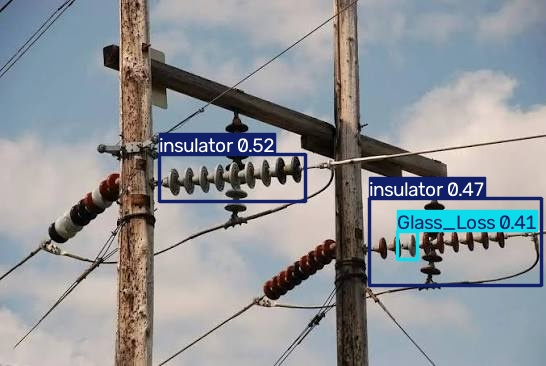

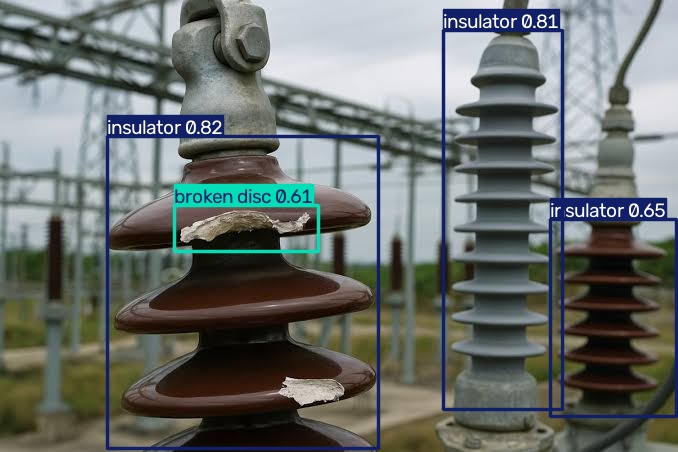

In [23]:
uploaded_prediction_dir = "runs/detect/Insulator_Faults_Detection_uploaded_image"
uploaded_pred_images = glob.glob(os.path.join(uploaded_prediction_dir, "*"))

for img in uploaded_pred_images:
    display(Image(filename=img, width=700))

## Step 16: Extract Detected Object Names and Confidence Scores

In [24]:
detections = []

for result in single_result:
    names = result.names

    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        label = names[cls_id]

        detections.append({
            "Detected Object": label,
            "Confidence Score": round(conf, 3)
        })

if len(detections) == 0:
    print("No defect detected.")
else:
    display(pd.DataFrame(detections))

,Detected Object,Confidence Score
0,insulator,0.823
1,insulator,0.806
2,insulator,0.653
3,broken disc,0.606


## Step 17: Build the Gradio Monitoring Interace

In [25]:
# ============================================================
# GRADIO APP - AI-BASED INSULATOR HEALTH DETECTION
# YOLOv8 + Roboflow
# ============================================================

!pip install -q gradio

import gradio as gr
from ultralytics import YOLO
from PIL import Image
import numpy as np
import os

# ------------------------------------------------------------
# 1. Load trained YOLO model
# ------------------------------------------------------------

best_model_path = "/content/runs/detect/Insulator_Faults_Detection_yolov8_roboflow/weights/best.pt"

model = YOLO(best_model_path)

print("Model loaded successfully!")
print("Model:", best_model_path)


# ------------------------------------------------------------
# 2. Detection Function
# ------------------------------------------------------------

def detect_insulator(image, confidence):

    if image is None:
        return None, "Please upload an image."

    # Run YOLO prediction
    results = model.predict(
        source=image,
        conf=confidence,
        save=False,
        verbose=False
    )

    # Get annotated image
    annotated_image = results[0].plot()

    # Convert BGR -> RGB
    annotated_image = annotated_image[:, :, ::-1]

    # --------------------------------------------------------
    # Extract detection information
    # --------------------------------------------------------

    detections = []

    boxes = results[0].boxes

    if boxes is not None and len(boxes) > 0:

        for box in boxes:

            class_id = int(box.cls[0])
            conf = float(box.conf[0])

            class_name = model.names[class_id]

            detections.append(
                f"• {class_name} — {conf*100:.1f}% confidence"
            )

    if len(detections) == 0:

        detection_text = (
            "No trained insulator condition detected "
            f"above {confidence*100:.0f}% confidence."
        )

    else:

        detection_text = (
            f"Detected {len(detections)} object(s):\n\n"
            + "\n".join(detections)
        )

    return annotated_image, detection_text


# ------------------------------------------------------------
# 3. Gradio Interface
# ------------------------------------------------------------

with gr.Blocks(title="AI Insulator Health Detection") as demo:

    gr.Markdown(
        """
        # ⚡ AI-Based Insulator Health Detection

        ### YOLOv8 + Roboflow Computer Vision Model

        Upload an image of an electrical insulator and the trained
        AI model will identify visible conditions learned during training.

        **Supported detection classes:**
        - Glass Dirty
        - Glass Loss
        - Polymer Dirty
        - Broken Disc
        - Insulator
        - Pollution Flashover
        """
    )

    with gr.Row():

        with gr.Column():

            input_image = gr.Image(
                type="numpy",
                label="Upload Insulator Image"
            )

            confidence = gr.Slider(
                minimum=0.10,
                maximum=0.90,
                value=0.40,
                step=0.05,
                label="Detection Confidence"
            )

            detect_button = gr.Button(
                "🔍 Detect Insulator Health",
                variant="primary"
            )

        with gr.Column():

            output_image = gr.Image(
                type="numpy",
                label="AI Detection Result"
            )

            output_text = gr.Textbox(
                label="Detection Summary",
                lines=8
            )

    detect_button.click(
        fn=detect_insulator,
        inputs=[input_image, confidence],
        outputs=[output_image, output_text]
    )

    gr.Markdown(
        """
        ---
        **Application Concept:**
        Drone/UAV imagery → AI Object Detection → Insulator Condition Identification
        → Spot Maintenance Prioritization

        *The model identifies only the conditions/classes on which it has been trained.*
        """
    )


# ------------------------------------------------------------
# 4. Launch Application
# ------------------------------------------------------------

demo.launch(share=True)

Model loaded successfully!
Model: /content/runs/detect/Insulator_Faults_Detection_yolov8_roboflow/weights/best.pt
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://adb914153c4d1852d0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Step 18: Optional Video Testing

In [ ]:
# Optional video testing
# uploaded_video = files.upload()
# video_path = list(uploaded_video.keys())[0]

# video_results = best_model.predict(
#     source=video_path,
#     conf=0.4,
#     save=True,
#     name="weapon_detection_video"
# )

# print("Video prediction completed.")

In [ ]:
import glob

# Search all best.pt files inside runs folder
best_model_paths = glob.glob("/content/runs/**/best.pt", recursive=True)

print("Available best.pt model files:")
for i, path in enumerate(best_model_paths):
    print(i, path)

if len(best_model_paths) == 0:
    print("No best.pt found. Please train the model first.")
else:
    best_model_path = best_model_paths[-1]
    print("Using model:", best_model_path)

Available best.pt model files:
0 /content/runs/detect/weapon_detection_yolov8_roboflow/weights/best.pt
Using model: /content/runs/detect/weapon_detection_yolov8_roboflow/weights/best.pt


In [ ]:
!pip install yt-dlp -q

from ultralytics import YOLO
import glob
from IPython.display import HTML
from base64 import b64encode

# Automatically find best.pt
best_model_paths = glob.glob("/content/runs/**/best.pt", recursive=True)

if len(best_model_paths) == 0:
    raise FileNotFoundError("No best.pt found. Train your YOLO model first, then run this cell again.")

best_model_path = best_model_paths[-1]
print("Loaded model:", best_model_path)

best_model = YOLO(best_model_path)

# Paste video URL here
video_url = "https://www.youtube.com/shorts/UfphLS5MVKQ"

# Download video
video_path = "weapon_test_video.mp4"
!yt-dlp -f "mp4/best" -o "{video_path}" "{video_url}"

print("Video downloaded successfully:", video_path)

# Run prediction and save output
video_results = best_model.predict(
    source=video_path,
    conf=0.4,
    save=True,
    name="weapon_detection_video"
)

print("Video prediction completed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 59.6 MB/s eta 0:00:00
Loaded model: /content/runs/detect/weapon_detection_yolov8_roboflow/weights/best.pt
[youtube] Extracting URL: https://www.youtube.com/shorts/UfphLS5MVKQ
[youtube] UfphLS5MVKQ: Downloading webpage
[youtube] UfphLS5MVKQ: Downloading android vr player API JSON
[info] UfphLS5MVKQ: Downloading 1 format(s): 18
[download] Destination: weapon_test_video.mp4
[download] 100% of    4.27MiB in 00:00:00 at 9.46MiB/s
Video downloaded successfully: weapon_test_video.mp4

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes objec

In [ ]:
video_results = best_model.predict(
    source=video_path,
    conf=0.15,
    save=True,
    save_txt=True,
    save_conf=True,
    project="/content/runs/detect",
    name="weapon_detection_video",
    exist_ok=True
)

print("Prediction completed.")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1797) /content/weapon_test_video.mp4: 640x384 (no detections), 9.6ms
video 1/1 (frame 2/1797) /content/weapon_test_video.mp4: 640x384 (no detections), 7.3ms
video 1/1 (frame 3/1797) /content/weapon_test_video.mp4: 640x384 1 Rifle, 7.3ms
video 1/1 (frame 4/1797) /content/weapon_test_video.mp4: 640x384 1 Rifle, 6.8ms
video 1/1 (frame 5/1797) /content/weapon_test_video.mp4: 640x384 (no detections), 6.4ms
video 1/1 (frame 6/1797) /content/

# Conclusion

The trained YOLO model demonstrated promising detection performance across the six insulator-condition classes. On the validation set of 672 images with 1,614 annotated instances, the model achieved an overall Precision of 81.0%, Recall of 76.4%, mAP@50 of 78.1%, and mAP@50–95 of 51.3%.

The model performed particularly well in detecting normal insulators, achieving 90.8% precision, 93.6% recall and 97.7% mAP@50, indicating strong capability in identifying the primary insulator class. Polymer Dirty and Broken Disc also showed relatively strong detection performance, with mAP@50 of 86.4% and 84.0%, respectively.

The results also identify areas requiring further improvement. Glass Loss showed the lowest mAP@50 at 55.1%, while Glass Dirty and Pollution-Flashover achieved mAP@50 of 63.1% and 82.4%, respectively. These variations indicate that additional representative images, improved annotation quality and further model training could enhance detection of visually challenging fault conditions.

Overall, the results confirm that the model provides a strong proof-of-concept for AI-assisted insulator inspection, with sufficient potential to support spot-maintenance prioritization. However, further validation using utility-specific field images and diverse real-world inspection conditions is required before operational deployment.

